# Cross-Modality Baseline Comparison: Spleen (CT) vs. Brain Tumour (MRI)
This notebook compares zero-shot in-context segmentation performance of the frozen, pretrained **UniverSeg** baseline model across two distinct medical imaging modalities.


In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract or hardcode Dice scores from baseline results
# Spleen (CT) per-slice scores from baseline_spleen.ipynb execution (Average: 0.5645)
spleen_scores = [0.7834, 0.6712, 0.1802, 0.5319, 0.6560]
spleen_avg = np.mean(spleen_scores)

# Brain Tumour (MRI - FLAIR) per-slice scores from logs/braintumour_baseline_scores.txt
bt_scores = []
bt_log_path = '../logs/braintumour_baseline_scores.txt'
if os.path.exists(bt_log_path):
    with open(bt_log_path, 'r') as f:
        content = f.read()
    matches = re.findall(r'Dice = ([0-9.]+)', content)
    if matches:
        bt_scores = [float(m) for m in matches]

if not bt_scores:
    bt_scores = [0.3052, 0.2646, 0.0036, 0.0000, 0.0144]

bt_avg = np.mean(bt_scores)

print(f'Spleen (CT) Slices:       {spleen_scores} -> Avg Dice: {spleen_avg:.4f}')
print(f'Brain Tumour (MRI) Slices: {bt_scores} -> Avg Dice: {bt_avg:.4f}')


Spleen (CT) Slices:       [0.7834, 0.6712, 0.1802, 0.5319, 0.656] -> Avg Dice: 0.5645
Brain Tumour (MRI) Slices: [0.3052, 0.2646, 0.0036, 0.0, 0.0144] -> Avg Dice: 0.1176


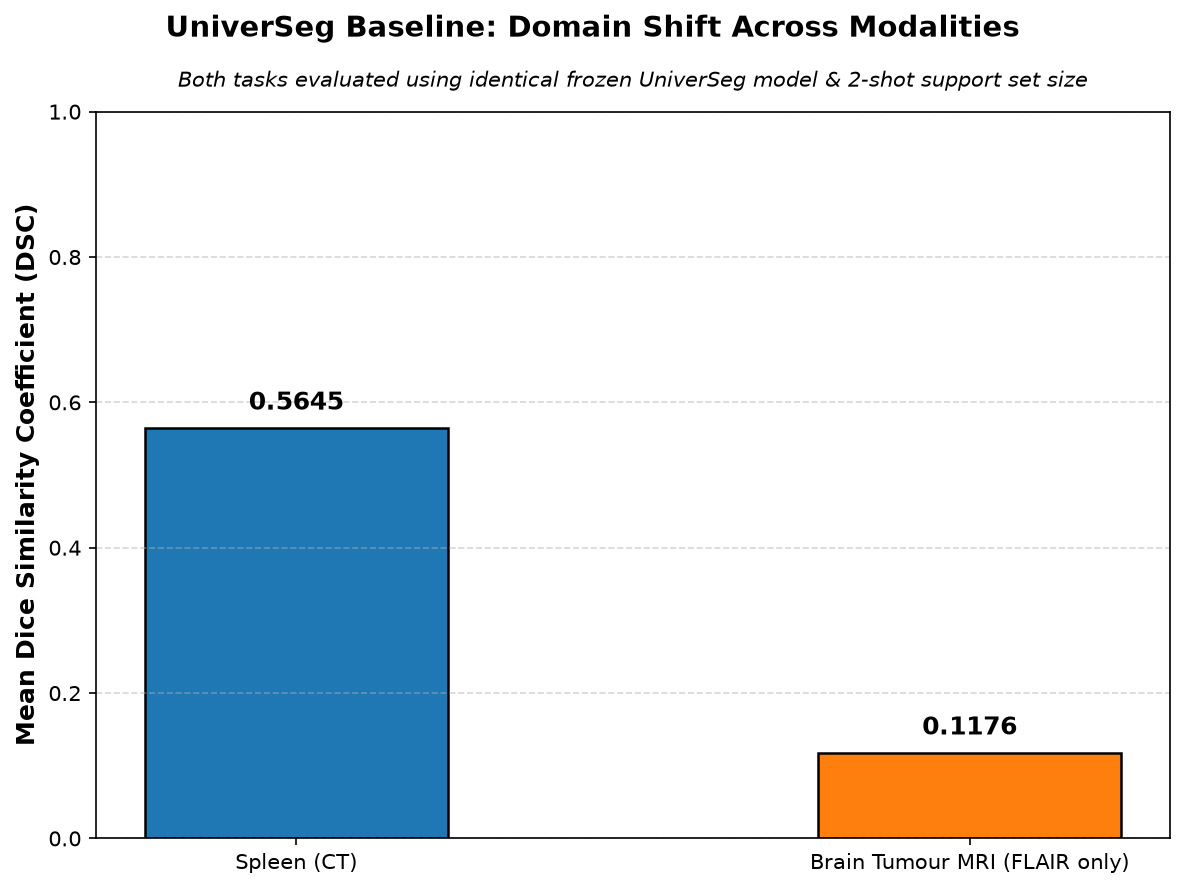

Chart saved to ../reports/domain_shift_comparison.png


In [2]:
# 2. Create Domain Shift Comparison Bar Chart
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

modalities = ['Spleen (CT)', 'Brain Tumour MRI (FLAIR only)']
scores = [spleen_avg, bt_avg]
colors = ['#1f77b4', '#ff7f0e']

bars = ax.bar(modalities, scores, color=colors, width=0.45, edgecolor='black', linewidth=1.2)

# Styling and Labels
ax.set_ylim(0, 1.0)
ax.set_ylabel('Mean Dice Similarity Coefficient (DSC)', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add exact score labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Title and Subtitle
plt.suptitle('UniverSeg Baseline: Domain Shift Across Modalities', fontsize=14, fontweight='bold', y=0.98)
ax.set_title('Both tasks evaluated using identical frozen UniverSeg model & 2-shot support set size', 
             fontsize=10, fontstyle='italic', pad=12)

# Save chart to reports/domain_shift_comparison.png
os.makedirs('../reports', exist_ok=True)
output_chart = '../reports/domain_shift_comparison.png'
plt.tight_layout()
plt.savefig(output_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {output_chart}')
